In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [121]:
df = pd.read_csv('./eval/EGFR_MAPK/dream_cytof/by_cl_cond_obs.csv', index_col=0)
df = df[df['rmse'].apply(np.isfinite)]

In [122]:
df[df.dataset != 'train']

,sample,condition,observable,dataset,ref,context,features,samples,pretrain,standardise_features,...,lrate_decay,warmup_fct,opt_steps,opt_mult,momentum,weight_decay,use_simple_linear_schedule,use_early_stopping,job,rmse
670,cBT20,EGF,pERBB2_Y1248_obs,val,avg_model,cytof_init,NaN,1of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,1.094191
671,cBT20,EGF,pERBB2_Y1248_obs,val,sample,cytof_init,NaN,1of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.167208
702,cBT20,EGF,pERK_Y204_obs,val,avg_model,cytof_init,NaN,1of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.919704
703,cBT20,EGF,pERK_Y204_obs,val,sample,cytof_init,NaN,1of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.311652
734,cBT20,EGF,pMEK_S222_obs,val,avg_model,cytof_init,NaN,1of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.690375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16998,cUACC3199,iMEK,pERK_Y204_obs,val,sample,cytof_init,NaN,4of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.286279
17029,cUACC3199,iMEK,pMEK_S222_obs,val,avg_model,cytof_init,NaN,4of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.809727
17030,cUACC3199,iMEK,pMEK_S222_obs,val,sample,cytof_init,NaN,4of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.184508
17061,cUACC3199,iMEK,pRPS6KA1_S380_obs,val,avg_model,cytof_init,NaN,4of5,False,False,...,0,0.0,0,0,0.9,0.0001,False,False,0,0.822248


<Axes: xlabel='condition-observable-samples-ref', ylabel='sample'>

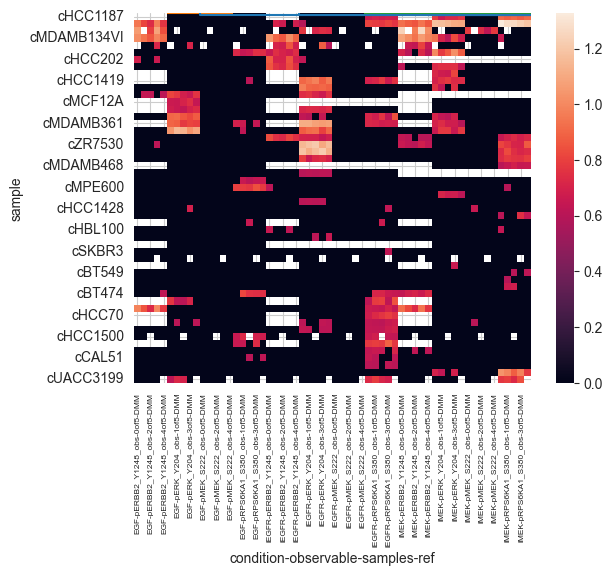

In [199]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

dfp = pd.pivot_table(df, index='sample', columns=['condition', 'observable', 'samples', 'ref'], values='rmse')
dfp_dmm = dfp.loc[:, dfp.columns.get_level_values('ref') == 'DMM'].copy()
dfp_dmm[df_dmm < 0.6] = 0

def nan_euclidean(u, v):
    mask = ~np.isnan(u) & ~np.isnan(v)
    if np.sum(mask) == 0:
        return np.nan  # Or a large constant like 1e6
    return np.mean(np.square(u[mask] - v[mask]))

distance_matrix = pdist(dfp_dmm.values, metric=nan_euclidean)
linkage_matrix = linkage(distance_matrix, method='median')
d = dendrogram(linkage_matrix, labels=dfp.index.tolist())
sns.heatmap(dfp_dmm.loc[d['ivl']])


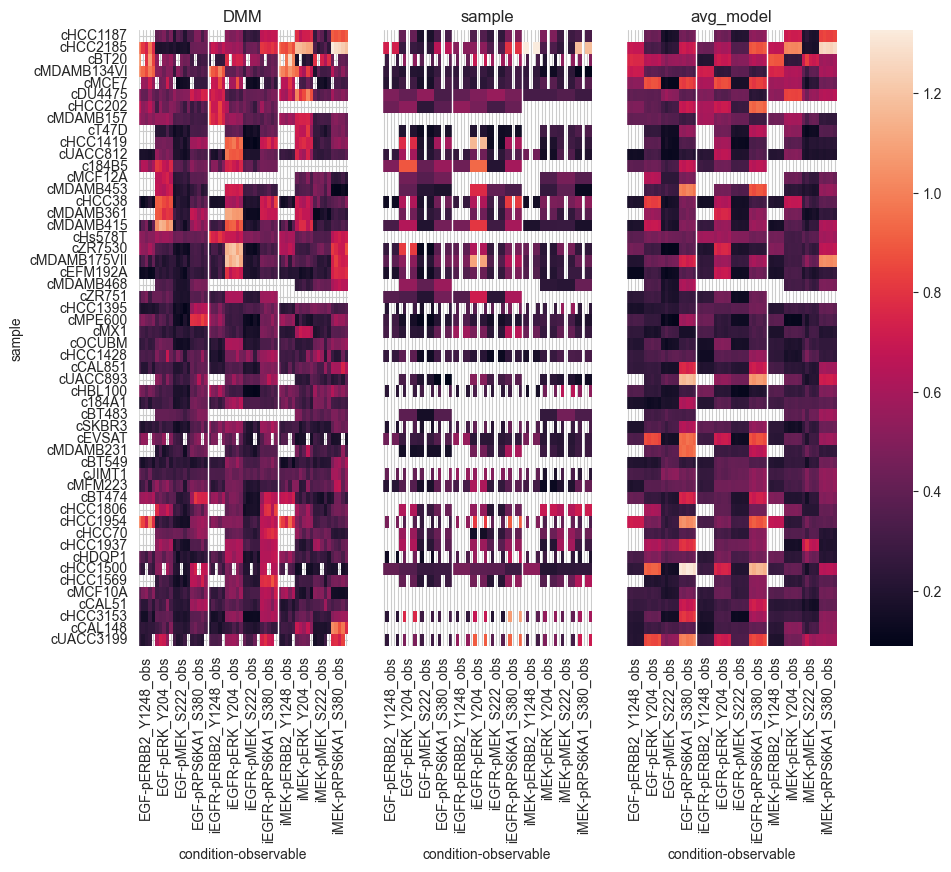

In [200]:
fig = plt.figure(figsize=(10, 8))
n_cols = 4
gs = gridspec.GridSpec(1, n_cols, width_ratios=[1]*(n_cols-1) + [0.2])  # Narrower last one

axes = [fig.add_subplot(gs[i]) for i in range(n_cols)]
for subgroup, ax in zip(
    ['DMM', 'sample', 'avg_model'], axes
):
    dfs = dfp.loc[:, dfp.columns.get_level_values('ref') == subgroup]
    dfs.columns = dfs.columns.droplevel('ref').droplevel('samples')
    dfs = dfs.loc[d['ivl']] # sort based on dendrogram
    sns.heatmap(dfs, ax=ax, cbar=(subgroup == 'DMM'), yticklabels=(subgroup == 'DMM'), cbar_ax=axes[3] if (subgroup == 'DMM') else None, xticklabels=1)
    ax.set_title(subgroup)
    xticks = ax.get_xticks()
    xticklabels = ax.get_xticklabels()

    new_labels = []
    for i, label in enumerate(xticklabels):
        if (i - 2) % 5 == 0:
            new_labels.append(label.get_text())
        else:
            new_labels.append("")

    ax.set_xticklabels(new_labels, rotation=90)

    for i in range(0, dfs.shape[1], 20):
        ax.axvline(x=i, color='white', linestyle='-', linewidth=1)
    if subgroup != 'DMM':
        ax.set_ylabel('')

# EGF condition

## HCC2185, BT20, MDAMB134VI, HCC1954
high pERBB2 error in EGF and iMEK conditions -> **EGFR overexpression?**

## 184B5, MCF12A, MDAMB453, HCC38, MDAMB361, MDAMB415,
high pERK error in EGF condition ???

## DU4475, BT474, HCC1395, MPE600, BT747, HCC1500, HCC1569
high RPS6KA1 error in EGF condition -> signaling via p38  **ADD RPS6KA1 activation by EGFR**

# iEGFR condition

## HCC2185, MDAMB134VI, MCF7, DU4475, HCC202, MDAMB157
high pERBB2 error in iEGFR condition -> EGFR overexpression?

## HCC1419, UACC812, MDAMB453, MDAMB316, MDAMB415, ZR7530, MDAMB175VII
high pERK error in iEGFR condition, also in per sample ???

## ...
high RPS6KA1 error in iEGFR condition -> signaling via p38  **ADD RPS6KA1 activation by EGFR**

# iMEK condition

## DU4475, HCC2185, MDAMB134VI
high pERK error in iMEK condition -> **BRAFV600E mutation** (DU4475)

## CAL148, HCC1187
high RPS6KA1 error in iMEK condition -> signaling via p38? **unknown cause**


In [ ]:
## BT20
